In [428]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# show all columns when printing a dataframe
pd.set_option('display.max_columns', None)

In [429]:
# read the kick dataset
df = pd.read_csv('kick_1.csv', low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41476 entries, 0 to 41475
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   PurchaseID                         41476 non-null  int64  
 1   PurchaseTimestamp                  41476 non-null  int64  
 2   PurchaseDate                       41476 non-null  object 
 3   Auction                            41432 non-null  object 
 4   VehYear                            41432 non-null  float64
 5   Make                               41432 non-null  object 
 6   Color                              41432 non-null  object 
 7   Transmission                       41432 non-null  object 
 8   WheelTypeID                        41432 non-null  object 
 9   WheelType                          41380 non-null  object 
 10  VehOdo                             41432 non-null  float64
 11  Nationality                        41432 non-null  obj

In [430]:
# brief look at all the data.
df.describe(include='all')

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
count,41476.000000,4.147600e+04,41476,41432,41432.000000,41432,41432,41432,41432,41380,41432.000000,41432,41432,41432,41416,41429,41429,41327,41429,41429,41409,41409,41116,41432,41432,41432,41432,41432,41432.000000,41476,41476.000000
unique,NaN,NaN,497,3,NaN,30,17,4,5,4,NaN,6,13,5,9271,10010,11070,11583,9183,9890,10935,11363,25870,3,3,31,1869,6,NaN,6,NaN
top,NaN,NaN,24/11/2009 10:00,MANHEIM,NaN,CHEVROLET,SILVER,AUTO,1,Alloy,NaN,AMERICAN,MEDIUM,GM,0,0,0,0,0,0,0,0,#VALUE!,?,?,TX,7500,0,NaN,Yes,NaN
freq,NaN,NaN,242,22168,NaN,9548,8541,39930,20426,20406,NaN,34616,17540,14075,502,415,502,501,287,206,287,287,178,39634,39634,9076,459,39940,NaN,27402,NaN
mean,20737.500000,1.262260e+09,NaN,NaN,2005.360615,NaN,NaN,NaN,NaN,NaN,71300.010427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1273.050758,NaN,0.129497
std,11973.234219,1.796895e+07,NaN,NaN,1.730587,NaN,NaN,NaN,NaN,NaN,14724.041171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,599.188662,NaN,0.335753
min,0.000000,1.231114e+09,NaN,NaN,2001.000000,NaN,NaN,NaN,NaN,NaN,577.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,462.000000,NaN,0.000000
25%,10368.750000,1.247530e+09,NaN,NaN,2004.000000,NaN,NaN,NaN,NaN,NaN,61578.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,834.000000,NaN,0.000000
50%,20737.500000,1.262045e+09,NaN,NaN,2005.000000,NaN,NaN,NaN,NaN,NaN,73128.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1155.000000,NaN,0.000000
75%,31106.250000,1.277770e+09,NaN,NaN,2007.000000,NaN,NaN,NaN,NaN,NaN,82259.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1623.000000,NaN,0.000000


In [431]:
print(df.shape)

(41476, 31)


In [432]:
# check the unique values in the categorical columns
cat_check = ['Auction', 'Transmission', 'WheelType', 'Size', 'Nationality','TopThreeAmericanName', 'Color', 'PRIMEUNIT', 'AUCGUART','ForSale', 'IsOnlineSale', 'VehYear']

for c in cat_check:
    print(c, df[c].unique())

Auction ['OTHER' 'MANHEIM' nan 'ADESA']
Transmission ['AUTO' 'MANUAL' 'Manual' nan '?']
WheelType ['Covers' 'Alloy' '?' 'Special' nan]
Size ['MEDIUM' 'COMPACT' 'LARGE' 'MEDIUM SUV' 'SPECIALTY' 'CROSSOVER' 'VAN'
 'LARGE SUV' 'SMALL TRUCK' 'LARGE TRUCK' 'SMALL SUV' 'SPORTS' '?' nan]
Nationality ['AMERICAN' 'OTHER ASIAN' 'USA' 'TOP LINE ASIAN' 'OTHER' '?' nan]
TopThreeAmericanName ['CHRYSLER' 'GM' 'OTHER' 'FORD' '?' nan]
Color ['RED' 'SILVER' 'WHITE' 'BLUE' 'BEIGE' 'BLACK' 'GREEN' 'GREY' 'NOT AVAIL'
 'GOLD' 'PURPLE' 'ORANGE' 'MAROON' 'YELLOW' 'OTHER' 'BROWN' nan '?']
PRIMEUNIT ['?' 'NO' 'YES' nan]
AUCGUART ['?' 'GREEN' 'RED' nan]
ForSale ['Yes' 'No' '?' 'yes' '0' 'YES']
IsOnlineSale ['0' '-1' '2' '4' '1' nan '?']
VehYear [2008. 2007. 2004. 2006. 2005. 2003. 2009. 2001. 2002.   nan 2010.]


In [433]:
# find rows where the 'Auction' column has no values, a lot more rows seem to also have no values.
isAuctionEmpty = df[df['Auction'].isna()]
isAuctionEmpty.head(100)

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [434]:
# find rows where the 'TopThreeAmericanName' column has no values, a lot more rows seem to also have no values. By eye, same rows as Auction.
isTopThreeAmericanNameEmpty = df[df['TopThreeAmericanName'].isna()]
isTopThreeAmericanNameEmpty.head(100)

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [435]:
# see if these two variables have the same number of NaN values.
print(df['Auction'].isna().sum(), 'rows have no Auction value')
print(df['TopThreeAmericanName'].isna().sum(), 'rows have no TopThreeAmericanName value')

44 rows have no Auction value
44 rows have no TopThreeAmericanName value


In [436]:
# determine how many rows have x amount of columns with no values in them.
df.isna().sum().value_counts().head(10)

44     16
0       5
47      4
67      2
96      1
60      1
149     1
360     1
Name: count, dtype: int64

In [437]:
# drop the 44 rows, as Auction (and TopThreeAmericanName) seems to have values consistently, and same ones have NaN.
print(df['Auction'].isna().sum(), 'rows have no Auction value')
print()
print(df['Auction'].value_counts())

44 rows have no Auction value

Auction
MANHEIM    22168
ADESA      11086
OTHER       8178
Name: count, dtype: int64


In [438]:
# count how many PRIMEUNIT and AUCGUART values are missing values or '?'. As the number is large, will drop.
primeunitquestionmark = (df['PRIMEUNIT'] == '?').sum()
primeunitna = df['PRIMEUNIT'].isna().sum()
aucguartquestionmark = (df['AUCGUART'] == '?').sum()
aucguartna = df['AUCGUART'].isna().sum()

print(primeunitquestionmark + primeunitna, 'rows have no PRIMEUNIT value')
print(aucguartquestionmark + aucguartna, 'rows have no AUCGUART value')

39678 rows have no PRIMEUNIT value
39678 rows have no AUCGUART value


In [439]:
# how many bad buys are in the dataset. Approximate value to aim for in the training data.
print(df['IsBadBuy'].value_counts())
print()
print('Total IsBadBuy:', df['IsBadBuy'].value_counts().sum())
print()
print(df['IsBadBuy'].value_counts(normalize=True))

IsBadBuy
0    36105
1     5371
Name: count, dtype: int64

Total IsBadBuy: 41476

IsBadBuy
0    0.870503
1    0.129497
Name: proportion, dtype: float64


In [440]:
# reload data to start making changes
df = pd.read_csv('kick_1.csv', low_memory=False)

In [441]:
# change the missing values into NaN values
df = df.replace('?', np.nan)
df = df.replace('NOT AVAIL', np.nan)

In [442]:
# drop the mostly empty rows, then renumber the rows from 0 again
df = df.dropna(subset=['Auction'])
df = df.reset_index(drop=True)

In [443]:
# drop columns that are mostly missing or not useful for prediction
df = df.drop(columns=['PRIMEUNIT', 'AUCGUART', 'PurchaseID', 'PurchaseDate', 'PurchaseTimestamp','WheelType', 
                      'WheelTypeID', 'MMRCurrentRetailRatio', 'ForSale', 'TopThreeAmericanName', 'Nationality'])

In [444]:
# convert the price columns from text to numbers, turn the errors into NaN values, as some of the values are not numbers.
number_cols = ['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice','MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
              'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice','MMRCurrentRetailAveragePrice', 
              'MMRCurrentRetailCleanPrice','VehBCost', 'WarrantyCost', 'VehOdo']

for c in number_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [445]:
df.describe(include='all')

,Auction,VehYear,Make,Color,Transmission,VehOdo,Size,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VNST,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
count,41432,41432.000000,41432,41361,41426,41432.000000,41429,41409.000000,41422.000000,41422.000000,41320.000000,41245.000000,41245.000000,41225.000000,41225.000000,41432,41403.000000,41430,41432.000000,41432.000000
unique,3,NaN,30,15,3,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,5,NaN,NaN
top,MANHEIM,NaN,CHEVROLET,SILVER,AUTO,NaN,MEDIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TX,NaN,0,NaN,NaN
freq,22168,NaN,9548,8541,39930,NaN,17540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9076,NaN,39940,NaN,NaN
mean,NaN,2005.360615,NaN,NaN,NaN,71300.010427,NaN,6135.010433,7375.121723,8444.518130,9797.919264,6146.975464,7401.179658,8764.614797,10129.457320,NaN,6733.107867,NaN,1273.050758,0.129489
std,NaN,1.730587,NaN,NaN,NaN,14724.041171,NaN,2481.223003,2743.390412,3169.430702,3401.450935,2445.988284,2695.210161,3105.209195,3320.763133,NaN,1771.737200,NaN,599.188662,0.335745
min,NaN,2001.000000,NaN,NaN,NaN,577.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,225.000000,NaN,462.000000,0.000000
25%,NaN,2004.000000,NaN,NaN,NaN,61578.000000,NaN,4273.000000,5400.000000,6216.000000,7478.000000,4295.000000,5436.000000,6517.000000,7766.000000,NaN,5440.000000,NaN,834.000000,0.000000
50%,NaN,2005.000000,NaN,NaN,NaN,73128.500000,NaN,6105.000000,7303.000000,8383.000000,9722.000000,6074.000000,7324.000000,8704.000000,10090.000000,NaN,6710.000000,NaN,1155.000000,0.000000
75%,NaN,2007.000000,NaN,NaN,NaN,82259.250000,NaN,7783.000000,9014.000000,10597.750000,12031.500000,7756.000000,9022.000000,10922.000000,12307.000000,NaN,7900.000000,NaN,1623.000000,0.000000


In [ ]:
# check how many missing values are in the number columns.
for c in number_cols:
    print(c, ':', df[c].isna().sum(), 'missing values')

MMRAcquisitionAuctionAveragePrice : 23 missing values
MMRAcquisitionAuctionCleanPrice : 10 missing values
MMRAcquisitionRetailAveragePrice : 10 missing values
MMRAcquisitonRetailCleanPrice : 112 missing values
MMRCurrentAuctionAveragePrice : 187 missing values
MMRCurrentAuctionCleanPrice : 187 missing values
MMRCurrentRetailAveragePrice : 207 missing values
MMRCurrentRetailCleanPrice : 207 missing values
VehBCost : 29 missing values
WarrantyCost : 0 missing values
VehOdo : 0 missing values


In [447]:
# fix the mixed upper/lower case, and USA means the same as AMERICAN
df['Transmission'] = df['Transmission'].replace('Manual', 'MANUAL')

print(df['Transmission'].unique())

['AUTO' 'MANUAL' nan]


In [448]:
# change Transmission into a 0/1 binary variable, to allign.
transmission_map = {'AUTO': 1, 'MANUAL': 0}
df['Transmission'] = df['Transmission'].map(transmission_map)

print(df['Transmission'].value_counts(dropna=False))

Transmission
1.0    39930
0.0     1496
NaN        6
Name: count, dtype: int64


In [449]:
# IsOnlineSale should only be 0 or 1, turn other values into NaN. 
df['IsOnlineSale'] = pd.to_numeric(df['IsOnlineSale'], errors='coerce')
df['IsOnlineSale'] = df['IsOnlineSale'].replace([-1, 2, 4], np.nan)

print(df['IsOnlineSale'].value_counts(dropna=False))

IsOnlineSale
0.0    39940
1.0      887
NaN      605
Name: count, dtype: int64


In [450]:
# an odometer reading of 0 or less is bad data - turn into NaN.
mask = df['VehOdo'] <= 0
df.loc[mask, 'VehOdo'] = np.nan

# same idea for the  columns - a price of 0 or less is bad data - turn into NaN
for c in number_cols:
    mask = df[c] <= 0
    df.loc[mask, c] = np.nan

In [451]:
# for the 0/1 columns, fill missing values with the most common value
df['Transmission'] = df['Transmission'].fillna(1)   # nearly every car is AUTO, 6 values won't skew things too much. 6 are changed.
df['IsOnlineSale'] = df['IsOnlineSale'].fillna(0)   # nearly every sale is not online in this dataset, so 0 is the most common value. 605 are changed.

In [452]:
numerical_columns = df.select_dtypes(include=['number'])
correlation_matrix = numerical_columns.corr()
correlation_matrix

,VehYear,Transmission,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
VehYear,1.000000,0.055956,-0.299009,0.603878,0.552644,0.606806,0.565072,0.600539,0.554880,0.615733,0.576302,0.347429,0.066595,-0.272248,-0.165610
Transmission,0.055956,1.000000,0.036304,0.105089,0.103363,0.076347,0.078724,0.107426,0.105742,0.083176,0.084597,0.146737,-0.008914,0.111769,0.005285
VehOdo,-0.299009,0.036304,1.000000,-0.028551,0.019263,0.016709,0.053691,-0.039895,0.005845,-0.002950,0.033139,-0.066748,0.029727,0.412781,0.079427
MMRAcquisitionAuctionAveragePrice,0.603878,0.105089,-0.028551,1.000000,0.989743,0.902620,0.902129,0.955317,0.949138,0.887405,0.886719,0.823724,0.053484,-0.056041,-0.115609
MMRAcquisitionAuctionCleanPrice,0.552644,0.103363,0.019263,0.989743,1.000000,0.893421,0.909969,0.941760,0.951047,0.876534,0.887822,0.814268,0.053064,-0.025114,-0.107302
MMRAcquisitionRetailAveragePrice,0.606806,0.076347,0.016709,0.902620,0.893421,1.000000,0.989428,0.865706,0.862386,0.932300,0.925107,0.782144,0.092106,-0.061932,-0.093656
MMRAcquisitonRetailCleanPrice,0.565072,0.078724,0.053691,0.902129,0.909969,0.989428,1.000000,0.862857,0.871543,0.924314,0.928690,0.787063,0.089565,-0.033388,-0.089190
MMRCurrentAuctionAveragePrice,0.600539,0.107426,-0.039895,0.955317,0.941760,0.865706,0.862857,1.000000,0.989979,0.910318,0.907946,0.797009,0.051351,-0.058773,-0.113527
MMRCurrentAuctionCleanPrice,0.554880,0.105742,0.005845,0.949138,0.951047,0.862386,0.871543,0.989979,1.000000,0.902183,0.916250,0.790406,0.051382,-0.029445,-0.107213
MMRCurrentRetailAveragePrice,0.615733,0.083176,-0.002950,0.887405,0.876534,0.932300,0.924314,0.910318,0.902183,1.000000,0.989289,0.775940,0.088440,-0.063860,-0.113156


In [453]:
correlation_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

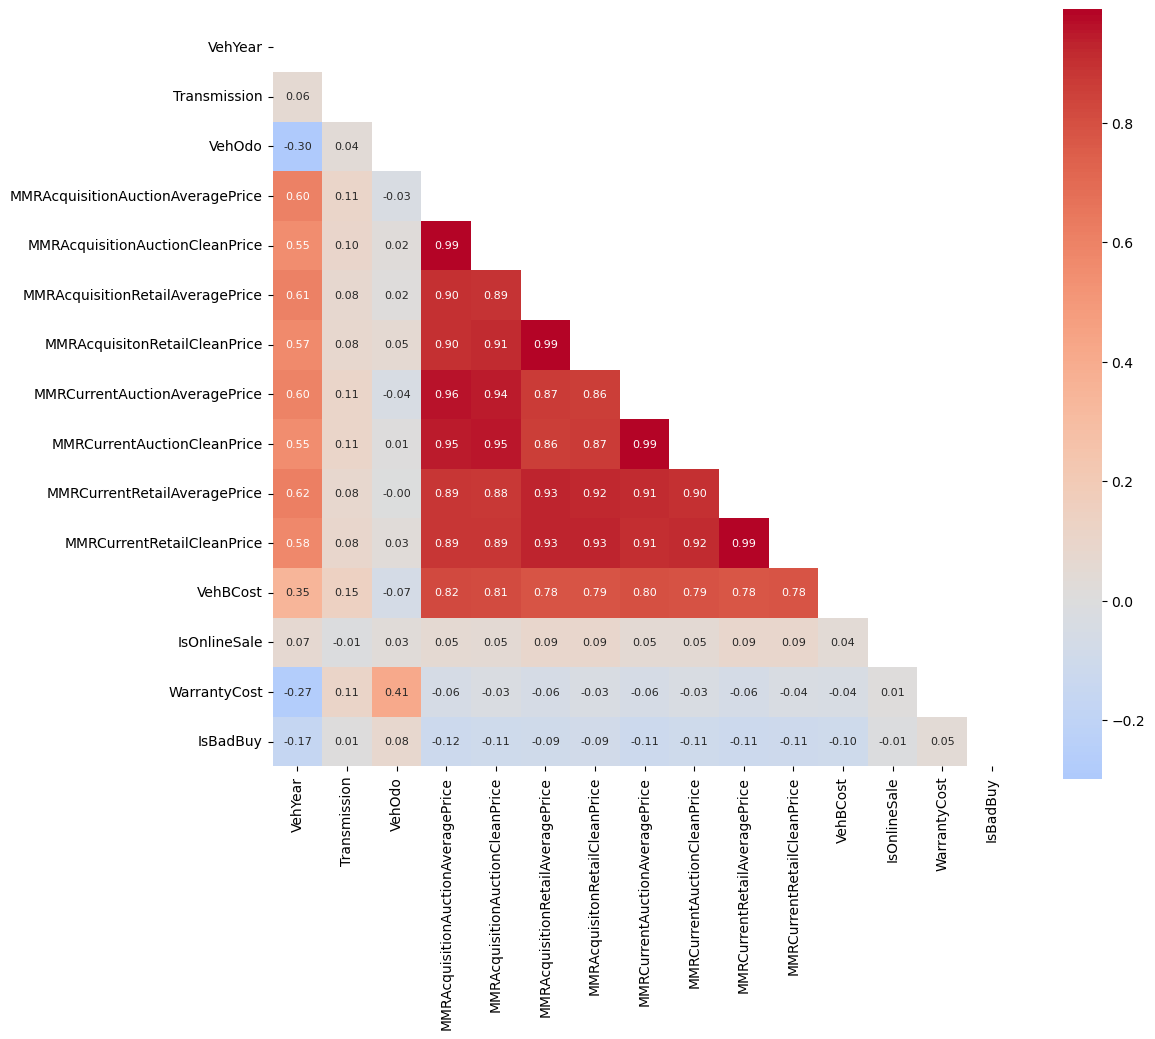

In [454]:
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
    annot_kws={'size': 8}, cmap='coolwarm',
    center=0, mask=correlation_mask, square=True)
plt.show()

In [455]:
# drop the price columns that are highly correlated with each other, keeping a few to compare against. 
# I chose Current Retail Average Price and Current Auction Average Price, as they are the most recent prices, and the other columns are highly correlated with them.
df = df.drop(columns=['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailCleanPrice'])

In [456]:
# fill missing values in the text columns with 'UNKNOWN'
text_cols = ['Make', 'Color', 'Size', 'VNST']

for c in text_cols:
    df[c] = df[c].fillna('UNKNOWN')

print(df.isna().sum())

Auction                            0
VehYear                            0
Make                               0
Color                              0
Transmission                       0
VehOdo                             0
Size                               0
MMRCurrentAuctionAveragePrice    474
MMRCurrentRetailAveragePrice     494
VNST                               0
VehBCost                          29
IsOnlineSale                       0
WarrantyCost                       0
IsBadBuy                           0
dtype: int64


In [457]:
# turn all the categorical columns into 0/1 columns, so they can be used in the model.
print('before encoding:', df.shape)
df = pd.get_dummies(df, dtype=int)
print('after encoding: ', df.shape)

before encoding: (41432, 14)
after encoding:  (41432, 102)


In [458]:
# separate the target (what we predict) from the features (what we predict with)
y = df['IsBadBuy'].values

X = df.drop(columns=['IsBadBuy'])
feature_names = X.columns

print('X shape:', X.shape, ' y shape:', y.shape)

X shape: (41432, 101)  y shape: (41432,)


In [459]:
from sklearn.model_selection import train_test_split

random_state = 10

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=random_state)

print('Size of training set:', len(X_train))
print('Size of testing set:', len(X_test))

Size of training set: 29002
Size of testing set: 12430


In [460]:
# compare the mean and median of each column with missing values, using the training set only, to decide which one to fill with
fill_cols = ['MMRCurrentAuctionAveragePrice', 'MMRCurrentRetailAveragePrice', 'VehBCost']

for c in fill_cols:
    print(c)
    print('mean:', round(X_train[c].mean(), 1))
    print('median:', round(X_train[c].median(), 1))

MMRCurrentAuctionAveragePrice
mean: 6186.1
median: 6098.0
MMRCurrentRetailAveragePrice
mean: 8822.8
median: 8735.5
VehBCost
mean: 6732.7
median: 6715.0


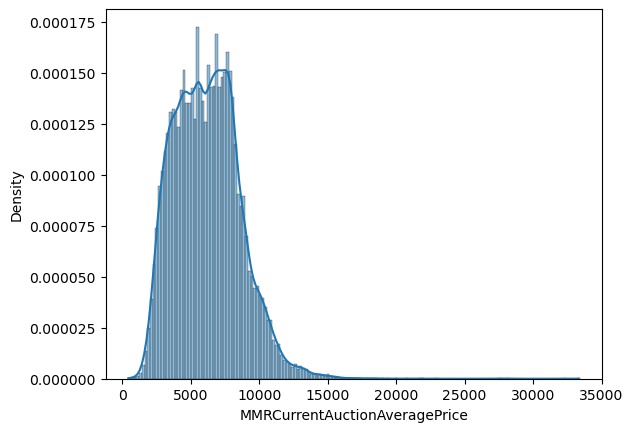

In [461]:
# plot of the distribution of MMRCurrentAuctionAveragePrice, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median.
dg = sns.histplot(df['MMRCurrentAuctionAveragePrice'].dropna(), kde=True, stat="density")
plt.show()

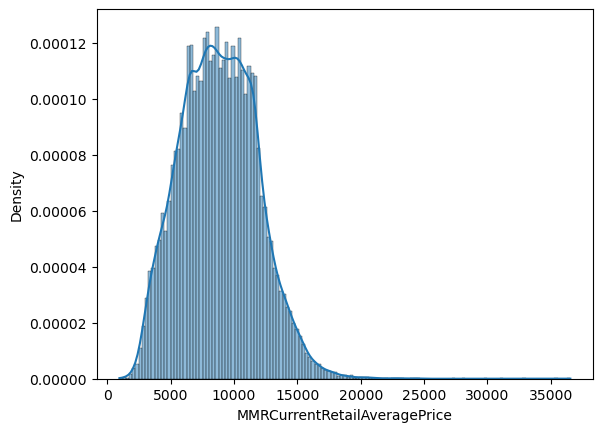

In [462]:
# plot of the distribution of MMRCurrentRetailAveragePrice, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median. Same as above.
dg = sns.histplot(df['MMRCurrentRetailAveragePrice'].dropna(), kde=True, stat="density")
plt.show()

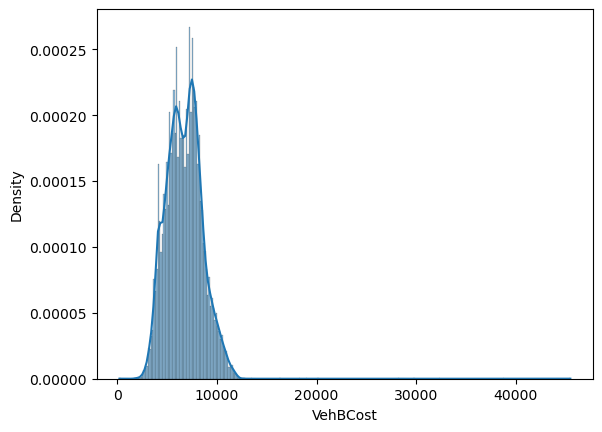

In [463]:
# plot of the distribution of VehBCost, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median. Same as both above.
dg = sns.histplot(df['VehBCost'].dropna(), kde=True, stat="density")
plt.show()

In [464]:
# fill missing values with the median, calculated from the training set.
auction_fill = X_train['MMRCurrentAuctionAveragePrice'].median()
retail_fill = X_train['MMRCurrentRetailAveragePrice'].median()
cost_fill   = X_train['VehBCost'].median()

X_train['MMRCurrentAuctionAveragePrice'] = X_train['MMRCurrentAuctionAveragePrice'].fillna(auction_fill)
X_test['MMRCurrentAuctionAveragePrice']  = X_test['MMRCurrentAuctionAveragePrice'].fillna(auction_fill)

X_train['MMRCurrentRetailAveragePrice'] = X_train['MMRCurrentRetailAveragePrice'].fillna(retail_fill)
X_test['MMRCurrentRetailAveragePrice']  = X_test['MMRCurrentRetailAveragePrice'].fillna(retail_fill)

X_train['VehBCost'] = X_train['VehBCost'].fillna(cost_fill)
X_test['VehBCost']  = X_test['VehBCost'].fillna(cost_fill)

In [465]:
# check there are no missing values left in either data sets.
print('missing in training set:', X_train.isna().sum().sum())
print('missing in testing set: ', X_test.isna().sum().sum())

missing in training set: 0
missing in testing set:  0


In [466]:
# sklearn expects numpy arrays, not DataFrames
X_train = X_train.values
X_test = X_test.values

In [467]:
# check both sets have a similar share of bad buys
print('train bad buy rate:', y_train.mean().round(4))
print('test bad buy rate: ', y_test.mean().round(4))

train bad buy rate: 0.1295
test bad buy rate:  0.1295


In [468]:
df.describe(include='all')

,VehYear,Transmission,VehOdo,MMRCurrentAuctionAveragePrice,MMRCurrentRetailAveragePrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy,Auction_ADESA,Auction_MANHEIM,Auction_OTHER,Make_ACURA,Make_BUICK,Make_CADILLAC,Make_CHEVROLET,Make_CHRYSLER,Make_DODGE,Make_FORD,Make_GMC,Make_HONDA,Make_HYUNDAI,Make_INFINITI,Make_ISUZU,Make_JEEP,Make_KIA,Make_LEXUS,Make_LINCOLN,Make_MAZDA,Make_MERCURY,Make_MINI,Make_MITSUBISHI,Make_NISSAN,Make_OLDSMOBILE,Make_PONTIAC,Make_SATURN,Make_SCION,Make_SUBARU,Make_SUZUKI,Make_TOYOTA,Make_VOLKSWAGEN,Make_VOLVO,Color_BEIGE,Color_BLACK,Color_BLUE,Color_BROWN,Color_GOLD,Color_GREEN,Color_GREY,Color_MAROON,Color_ORANGE,Color_OTHER,Color_PURPLE,Color_RED,Color_SILVER,Color_UNKNOWN,Color_WHITE,Color_YELLOW,Size_COMPACT,Size_CROSSOVER,Size_LARGE,Size_LARGE SUV,Size_LARGE TRUCK,Size_MEDIUM,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_UNKNOWN,Size_VAN,VNST_AL,VNST_AZ,VNST_CA,VNST_CO,VNST_FL,VNST_GA,VNST_ID,VNST_IL,VNST_IN,VNST_KY,VNST_LA,VNST_MO,VNST_MS,VNST_NC,VNST_NE,VNST_NH,VNST_NJ,VNST_NM,VNST_NV,VNST_NY,VNST_OH,VNST_OK,VNST_OR,VNST_PA,VNST_SC,VNST_TN,VNST_TX,VNST_UT,VNST_VA,VNST_WA,VNST_WV
count,41432.000000,41432.000000,41432.000000,40958.000000,40938.000000,41403.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.00000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.00000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000
mean,2005.360615,0.963893,71300.010427,6190.048415,8826.060018,6733.107867,0.021409,1273.050758,0.129489,0.267571,0.535045,0.197384,0.000459,0.009968,0.000410,0.230450,0.126931,0.178244,0.155870,0.008472,0.006348,0.023098,0.000652,0.001979,0.023774,0.032270,0.000314,0.001303,0.012840,0.012720,0.000459,0.013733,0.028625,0.003524,0.05684,0.030049,0.001858,0.000410,0.020322,0.016026,0.001762,0.000290,0.021578,0.106005,0.141316,0.006010,0.073832,0.043348,0.102529,0.025077,0.006155,0.003282,0.004948,0.088362,0.206145,0.001714,0.166297,0.003403,0.097388,0.023508,0.119907,0.020033,0.045786,0.423344,0.110277,0.032149,0.011923,0.024088,0.010258,0.000072,0.081266,0.004320,0.081652,0.078876,0.087444,0.126714,0.031063,0.000338,0.003982,0.01173,0.005551,0.008423,0.018295,0.009944,0.086745,0.000628,0.002341,0.007651,0.005768,0.013347,0.000145,0.000603,0.062633,0.003282,0.016895,0.040114,0.035504,0.219058,0.003982,0.026381,0.003282,0.003307
std,1.730587,0.186560,14724.041171,2399.615073,3027.803136,1771.737200,0.144744,599.188662,0.335745,0.442698,0.498776,0.398029,0.021410,0.099343,0.020252,0.421126,0.332900,0.382723,0.362736,0.091652,0.079420,0.150217,0.025520,0.044444,0.152346,0.176718,0.017711,0.036079,0.112587,0.112063,0.021410,0.116383,0.166753,0.059258,0.23154,0.170725,0.043070,0.020252,0.141103,0.125578,0.041939,0.017016,0.145301,0.307848,0.348351,0.077291,0.261500,0.203642,0.303347,0.156362,0.078211,0.057200,0.070168,0.283824,0.404541,0.041361,0.372351,0.058238,0.296490,0.151513,0.324857,0

# Task 2 - Decision Tree Modelling
## 2.1 Decision Tree using default settings

### 2.1A Default Decision Tree Parameters

In [469]:
from sklearn.tree import DecisionTreeClassifier

# default decision tree training
def_dt_model = DecisionTreeClassifier(random_state=random_state)
def_dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [470]:
print('*****Model parameters******\n', def_dt_model.get_params(deep=True))
print('Number of leaves in the trained model:', def_dt_model.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 4196


In [471]:
def_dt_model_important_params = {
    'criterion': def_dt_model.get_params()['criterion'],
    'splitter': def_dt_model.get_params()['splitter'],
    'max_depth': def_dt_model.get_params()['max_depth'],
    'min_samples_split': def_dt_model.get_params()['min_samples_split'],
    'min_samples_leaf': def_dt_model.get_params()['min_samples_leaf'],
    'max_features': def_dt_model.get_params()['max_features'],
    'class_weight': def_dt_model.get_params()['class_weight'],
    'random_state': def_dt_model.get_params()['random_state']
}

def_dt_model_important_params

{'criterion': 'gini',
 'splitter': 'best',
 'max_depth': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': None,
 'class_weight': None,
 'random_state': 10}

### 2.1B Data Split
During the preprocessing stage, the dataset was divided into training and testing with a split 70% training and 30% testing. In addition, stratified sampling (`stratify=y`) was used to preserve the proportion of training and testing data. For reproduciibility among team members, a `random_state` of 10 was used.

In [472]:
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training proportion:", len(X_train) / (len(X_train) + len(X_test)))
print("Testing proportion:", len(X_test) / (len(X_train) + len(X_test)))

Training observations: 29002
Testing observations: 12430
Training proportion: 0.6999903456265688
Testing proportion: 0.3000096543734312


### 2.1C Classification Accuracy

In [473]:
training_accuracy = def_dt_model.score(X_train, y_train)
print(f"Training set accuracy:, {training_accuracy:.4f}")

Training set accuracy:, 1.0000


In [474]:
testing_accuracy = def_dt_model.score(X_test, y_test)
print(f"Testing set accuracy: , {testing_accuracy:.4f}")

Testing set accuracy: , 0.7870


#### Training and Test Accuracy Gap

In [475]:
training_test_accuracy_gap = training_accuracy - testing_accuracy
print(f"Accuracy gap: {training_test_accuracy_gap:.4f}")

Accuracy gap: 0.2130


#### Classification Performance
Due to imbalance of target variable `IsBadBuy`, Accuracy alone is not enough to measure the model's performance. Evaluation metrics, Precision, Recall, and F1-score are also examined with particular attention to class 1 (Bad Buy).

In [476]:
y_test_pred = def_dt_model.predict(X_test)
print(y_test_pred)

[0 0 0 ... 0 0 0]


In [477]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88     10820
           1       0.19      0.20      0.19      1610

    accuracy                           0.79     12430
   macro avg       0.54      0.54      0.54     12430
weighted avg       0.79      0.79      0.79     12430



### 2.1D Size of Decision Tree
The size of the default Decision Tree are examined by getting the depth, total number of nodes and leaves.

In [478]:
print("Tree depth:", def_dt_model.get_depth())
print("Number of nodes:", def_dt_model.tree_.node_count)
print("Number of leaves:", def_dt_model.get_n_leaves())

Tree depth: 54
Number of nodes: 8391
Number of leaves: 4196


#### Visualise Default Decision Tree Model

In [479]:
# Allow us to display images directly in the notebook.
from IPython.display import Image, display
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

def visualize_model(model):
    # export_graphviz() expects a file to write to. Rather than writing to a file and
    # then reading it back in, we can use StringIO() to create a temporary file in memory.
    dotfile = StringIO()
    export_graphviz(model, out_file=dotfile, feature_names=feature_names)
    
    # Use pydot to load this dot file, and then display it in the notebook.
    # Dot files can contain multiple graphs, we want the first one, hence [0].
    graph = pydot.graph_from_dot_data(dotfile.getvalue())
    display(Image(graph[0].create_png()))

visualize_model(def_dt_model)

ModuleNotFoundError: No module named 'pydot'

### 2.1E First and Second Split
Examined the structure of the Decision Tree to identiy the variable used for first split and the variables used for the second split.

In [ ]:
# Get the feature used at the root node (first split)
root_feature_index = def_dt_model.tree_.feature[0]
root_threshold = def_dt_model.tree_.threshold[0]

print("First split variable:", feature_names[root_feature_index])
print("First split threshold:", root_threshold)

In [ ]:
# Get the two child nodes of the root node
root_left_child = def_dt_model.tree_.children_left[0]
root_right_child = def_dt_model.tree_.children_right[0]

# Get the feature used of left and right child nodes
left_child_feature_index = def_dt_model.tree_.feature[root_left_child]
right_child_feature_index = def_dt_model.tree_.feature[root_right_child]

print("Left child second-level split:", feature_names[left_child_feature_index])
print("Right child second-level split:", feature_names[right_child_feature_index])

### 2.1F Five Most Important Variables

In [ ]:
def display_feature_importances(model, feature_names, features_to_display=20):
    # Grab feature importances from the model and feature names from the original X.
    # We get the feature names from the original dataframe because
    # the feature array does not include column titles.
    importances = model.feature_importances_
    
    # Sort feature importances in descending order.
    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)
    
    # Limit the output to the requested number of features.
    indices = indices[:features_to_display]
    
    for i in indices:
        print(feature_names[i], ':', importances[i])
    
    print("Number of leaves:", model.get_n_leaves())

display_feature_importances(def_dt_model, feature_names, features_to_display=5)

### 2.1G Evidence of Model Overfitting
Evidences of overfitting are found in default Decision Tree. The model achieved 100% accuracy on the the training dataset but only 78.52% on the test dataset, a difference of 21.48%. This shows that the model performed better on training data versus unseen test data.
The tree depth (48), number of nodes (8311), and number leaves (4156), show that the tree is complex.

In [ ]:
print(f"Training accuracy: {training_accuracy:.4f}")
print(f"Test accuracy:     {testing_accuracy:.4f}")
print(f"Accuracy gap:      {training_accuracy - testing_accuracy:.4f}")

In [ ]:
print(f"Tree depth:       {def_dt_model.get_depth()}")
print(f"Number of nodes:  {def_dt_model.tree_.node_count}")
print(f"Number of leaves: {def_dt_model.get_n_leaves()}")